In [1]:
print('Radha!')

Radha!


In [2]:
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv

In [3]:
load_dotenv()
llm = ChatOpenAI()

In [4]:
class ResumeState(TypedDict):
    resume: str
    improved_resume: str
    feedback: str
    score: int
    iteration: int

In [5]:
def improve_resume(state: ResumeState):

    response = llm.invoke(
        f"""
        Improve this resume summary:

        {state["resume"]}

        Previous feedback:
        {state["feedback"]}

        Make it more professional, specific and impactful.
        """
    )

    return {
        "improved_resume": response.content,
        "iteration": state["iteration"] + 1
    }

In [6]:
def evaluate_resume(state: ResumeState):

    response = llm.invoke(
        f"""
        Evaluate this resume summary:

        {state["improved_resume"]}

        Give it a score from 1 to 10.

        Return:
        SCORE: <number>
        FEEDBACK: <short feedback>
        """
    )

    # For learning purposes, we'll parse the response simply.
    lines = response.content.splitlines()

    score = 0
    feedback = ""

    for line in lines:
        if line.startswith("SCORE:"):
            score = int(line.replace("SCORE:", "").strip())

        elif line.startswith("FEEDBACK:"):
            feedback = line.replace("FEEDBACK:", "").strip()

    return {
        "score": score,
        "feedback": feedback
    }

In [7]:
def should_continue(state: ResumeState):

    if state["score"] >= 8:
        return "finish"

    if state["iteration"] >= 3:
        return "finish"

    return "improve"

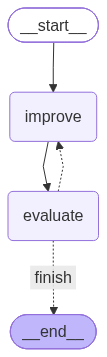

In [8]:
builder = StateGraph(ResumeState)

builder.add_node("improve", improve_resume)
builder.add_node("evaluate", evaluate_resume)

builder.add_edge(START, "improve")
builder.add_edge("improve", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    should_continue,
    {
        "improve": "improve",
        "finish": END
    }
)

graph = builder.compile()
graph

In [11]:
result = graph.invoke({
    "resume": "I know Python.",
    "improved_resume": "",
    "feedback": "",
    "score": 0,
    "iteration": 0
})

print(result['improved_resume'])
print(result['iteration'])

Experienced Python developer with a proven track record of designing and implementing efficient and scalable solutions. Skilled in utilizing Python for data analysis, web development, and automation tasks. Strong problem-solving abilities and a passion for continual learning and improvement in the field of programming.
1
